In [132]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
%autoreload 2
from utils import (
    select_users_by_period,
    create_hourly_user_dataset,
)
from visualization_utils import (
    plot_user_metrics,
    plot_market_features,
)


### Prepare data

In [134]:
import pandas as pd
import numpy as np
import json
pd.set_option('display.max_columns', 500)

# MARKET = "eth_cbbtc_usdc"
MARKET = "eth_rlp_usdc"
EVENTS_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_MARKET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(f"{EVENTS_PATH}/{MARKET}.csv")
market_df = pd.read_csv(f"{HOURLY_MARKET_PATH}/{MARKET}.csv")

df.head(2)

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol
0,0x883f79a55de8cb342d22cbc0aa939cf5949574d07057...,MarketSupply,1735791143,0xf603265f91f58F1EfA4fAd57694Fb3B77b25fC18,1000000,1.0,0,0.0,eth_rlp_usdc,2025-01-02 04:12:23,0xe1b65304edd8ceaea9b629df4c3c926a37d1216e2790...,0.0,0.0,1.0,0.0,0.0,0.0,1,0.008556,0.0,0.008556,0.0,NaN,1.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,loan_position_supply,False,0.0,0.0,0.0,0.002757,-0.008696,0.008772,loan_position_supply,RLP,USDC
1,0x8d0d68e0ba8fe86937ad21af699fba7287d976003de6...,MarketSupply,1735791227,0xf603265f91f58F1EfA4fAd57694Fb3B77b25fC18,1000000,1.0,0,0.0,eth_rlp_usdc,2025-01-02 04:13:47,0xe1b65304edd8ceaea9b629df4c3c926a37d1216e2790...,1.0,0.0,2.0,0.0,0.0,0.0,1,0.008556,0.0,0.008556,0.0,NaN,1.0,0.0,NaN,0.0,1.0,0.0,0.0,NaN,0.0,2.0,0.0,0.0,0.0,loan_position_supply,False,0.0,0.0,0.0,0.002757,-0.008696,0.008772,loan_position_supply,RLP,USDC


In [135]:
def detect_market_spikes(
    df,
    start_date=None,
    baseline_window_hours=24,
    baseline_gap_seconds=300,
    spike_util_threshold=0.90,
    min_spike_delta=0.03,
    recovery_buffer=0.02,
    max_followup_events=200,
    actions_limit=1000,
    min_episode_events=1,           # NEW: filter short episodes
    sustained_recovery_events=1,     # NEW: require N consecutive events below threshold
    min_actions_in_spike=1,
):
    """
    Detect utilization spike episodes in Morpho market event logs.
    (Full docstring omitted for brevity – same as before plus new parameters)

    New Parameters
    --------------
    min_episode_events : int
        Minimum number of events an episode must contain to be included.
    sustained_recovery_events : int
        Number of consecutive events where utilization must stay ≤ baseline+buffer
        before recovery is confirmed (prevents false recovery from a single small action).
    """
    # Ensure datetime column exists
    if 'datetime' not in df.columns and 'timestamp' in df.columns:
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    
    if start_date is not None:
        start_ts = pd.Timestamp(start_date).timestamp()
        df = df[df['timestamp'] >= start_ts].copy()
        if df.empty:
            return []
    
    df = df.sort_values('timestamp').reset_index(drop=True)
    df['delta_util'] = df['utilization_after'] - df['utilization_before']
    
    # Precompute baseline utilization
    timestamps = df['timestamp'].values
    util_after = df['utilization_after'].values
    baseline_util = np.full(len(df), np.nan)
    baseline_sec = baseline_window_hours * 3600
    
    for i in range(len(df)):
        t_i = timestamps[i]
        window_start = t_i - baseline_sec
        window_end = t_i - baseline_gap_seconds
        mask = (timestamps >= window_start) & (timestamps <= window_end)
        if mask.any():
            baseline_util[i] = np.median(util_after[mask])
        else:
            earlier = df['utilization_after'][timestamps < t_i]
            if not earlier.empty:
                baseline_util[i] = earlier.iloc[-1]
            else:
                baseline_util[i] = util_after[i]
    df['baseline_utilization'] = baseline_util
    
    spikes = []
    i = 0
    n = len(df)
    in_episode = False
    episode_start_idx = None
    episode_baseline = None
    episode_peak_util = None
    
    while i < n and len(spikes) < actions_limit:
        row = df.iloc[i]
        
        is_spike_onset = (
            row['utilization_after'] >= spike_util_threshold and
            row['delta_util'] >= min_spike_delta and
            not in_episode
        )
        
        if is_spike_onset:
            episode_start_idx = i
            episode_baseline = row['baseline_utilization']
            episode_peak_util = row['utilization_after']
            in_episode = True
            
            onset_tx_hash = row['hash']
            onset_timestamp = row['timestamp']
            tx_rows = df[(df['timestamp'] == onset_timestamp) & (df['hash'] == onset_tx_hash)]
            trigger_event_types = ','.join(sorted(tx_rows['type'].unique()))
            
            market_state = {
                'total_borrow': row.get('total_borrow_before', np.nan),
                'total_supply': row.get('total_supply_before', np.nan),
                'collateral_price': row.get('collateral_price', np.nan),
                'loan_asset_price': row.get('loan_asset_price', np.nan),
                'debt_before': row.get('debt_before', np.nan),
                'supply_before': row.get('supply_before', np.nan),
                'utilization_before': row.get('utilization_before', np.nan)
            }
            
            recovery_idx = None
            censoring_reason = None
            end_idx = None
            sustained_count = 0  # NEW: counter for sustained recovery
            
            for j in range(i, min(i + max_followup_events, n)):
                current_row = df.iloc[j]
                
                if current_row['utilization_after'] > episode_peak_util:
                    episode_peak_util = current_row['utilization_after']
                
                # Check recovery condition (with sustained requirement)
                if current_row['utilization_after'] <= episode_baseline + recovery_buffer:
                    sustained_count += 1
                else:
                    sustained_count = 0
                
                if sustained_count >= sustained_recovery_events:
                    recovery_idx = j
                    end_idx = j
                    censoring_reason = None
                    break
                
                # Check for new spike onset (only after the first event)
                if j > i:
                    new_onset = (
                        current_row['utilization_after'] >= spike_util_threshold and
                        current_row['delta_util'] >= min_spike_delta
                    )
                    if new_onset:
                        end_idx = j - 1
                        censoring_reason = 'new_spike_onset'
                        break
            
            if recovery_idx is None and censoring_reason is None:
                end_idx = min(i + max_followup_events - 1, n - 1)
                censoring_reason = 'max_events_reached'
            
            episode_df = df.iloc[i:end_idx+1].copy()
            
            # Apply minimum episode length filter
            if len(episode_df) < min_episode_events:
                i = end_idx + 1
                in_episode = False
                continue
            
            if recovery_idx is not None:
                recovery_datetime = df.iloc[recovery_idx]['datetime']
                recovery_time_seconds = df.iloc[recovery_idx]['timestamp'] - row['timestamp']
                event = 1
            else:
                recovery_datetime = None
                recovery_time_seconds = None
                event = 0
            
            spike_info = {
                'trigger_datetime': row['datetime'],
                'recovery_datetime': recovery_datetime,
                'recovery_time_seconds': recovery_time_seconds,
                'event': event,
                'spike_magnitudes': {
                    'utilization_delta': row['delta_util'],
                    'peak_utilization': episode_peak_util
                },
                'trigger_event_types': trigger_event_types,
                'market_state': market_state,
                'actions_df': episode_df,
                'baseline_utilization': episode_baseline,
                'spike_duration_events': len(episode_df)
            }
            if censoring_reason:
                spike_info['censoring_reason'] = censoring_reason
            
            spikes.append(spike_info)
            
            i = end_idx + 1
            in_episode = False
        else:
            i += 1
    spikes_cleaned = []
    for s in spikes:
        if s["actions_df"].shape[0] >= min_actions_in_spike:
            spikes_cleaned.append(s)
    
    return spikes_cleaned


<Axes: >

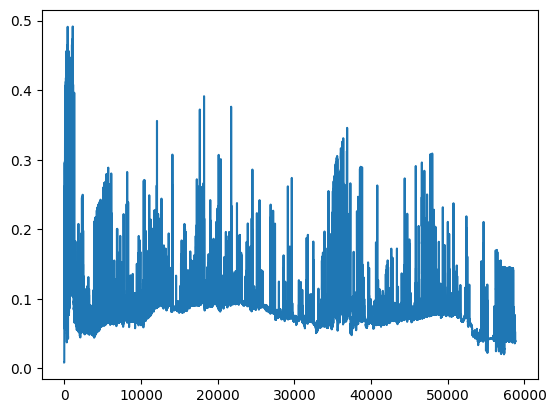

In [136]:
df['borrow_rate_after'].plot()

In [137]:
spikes = detect_market_spikes(
    df=df,
    start_date='2025-03-01',
    baseline_window_hours=24,
    spike_util_threshold=0.90,
    min_spike_delta=0.03,
    recovery_buffer=0.02,
    max_followup_events=200,
    actions_limit=100000,
    min_actions_in_spike=2,
)


In [138]:
# len(spikes)
# for i in spikes[500:700]:
#     df_actions = i['actions_df'].copy()
#     if df_actions.empty:
#         continue
#     trigger_ts = i['trigger_datetime']
#     if df_actions.empty:
#         continue
#     display(df_actions[[
#         "datetime",
#         "type",
#         "utilization_before",
#         "utilization_after",
#         "borrow_rate_after",
#         "user_address"
#     ]])
#     print("="*200)


<Axes: >

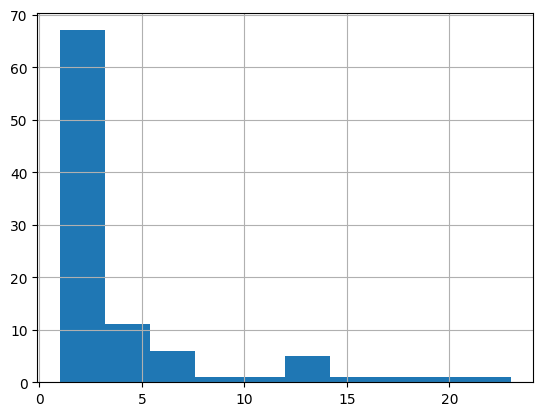

In [139]:
spikes[0]
dd = pd.Series([(x['recovery_time_seconds'] or 0) // (60*60) for x in spikes])
dd = dd[dd>0]
# dd.clip(0, 1).hist()
dd.hist()

### Prepare train/test

In [150]:
import pandas as pd
import numpy as np
from collections import defaultdict

BIN_EDGES = [0, 0.25, 0.5,  1, 2, 3, 12, 24]

def build_hazard_dataset(
    spikes_list,
    events_df,
    market_df,
    bin_edges_hours=(0, 0.5, 1, 2, 3, 6, 12, 24, 48, 72, 120, 168),
    recovery_buffer=0.02,
    hhi_lookback_hours=24,
    min_spike_events_length=1,
):
    # Ensure events_df has datetime and is sorted
    if 'datetime' not in events_df.columns and 'timestamp' in events_df.columns:
        events_df['datetime'] = pd.to_datetime(events_df['timestamp'], unit='s')
    events_df = events_df.sort_values('timestamp').reset_index(drop=True)

    if 'datetime' not in market_df.columns and 'timestamp' in market_df.columns:
        market_df['datetime'] = pd.to_datetime(market_df['timestamp'], unit='s')
    market_df = market_df.sort_values('timestamp').reset_index(drop=True)

    # Precompute market age at each timestamp (first appearance in market_df)
    market_min_ts = market_df['timestamp'].min()
    market_df['market_age_hours'] = (market_df['timestamp'] - market_min_ts) / 3600

    all_rows = []
    spike_counter = 0

    for spike in spikes_list:
        if spike['actions_df'].shape[0] < min_spike_events_length:
            continue
        spike_id = spike_counter
        spike_counter += 1

        trigger_ts = pd.Timestamp(spike['trigger_datetime']).timestamp()
        baseline_util = spike['baseline_utilization']
        recovery_threshold = baseline_util + recovery_buffer

        actions = spike['actions_df'].copy()
        if actions.empty:
            continue

        # Determine market (from first action or market_state)
        market = actions.iloc[0].get('market', 'unknown')

        # ------------------------------------------------------------------
        # 1. Static pre‑spike features
        # ------------------------------------------------------------------
        # Get pre‑spike snapshot from market_df (hourly) just before trigger
        pre_market = market_df[market_df['timestamp'] <= trigger_ts].iloc[-1] if not market_df[market_df['timestamp'] <= trigger_ts].empty else None
        pre_total_supply = pre_market['total_supply'] if pre_market is not None else np.nan
        pre_total_borrow = pre_market['total_borrow'] if pre_market is not None else np.nan
        pre_borrow_rate = pre_market['borrow_rate'] if pre_market is not None else np.nan
        pre_supply_rate = pre_market['supply_rate'] if pre_market is not None else np.nan
        pre_vol_6h = pre_market['volatility_6h'] if pre_market is not None else np.nan
        pre_dd_6h = pre_market['drawdown_6h'] if pre_market is not None else np.nan
        market_age_hours = pre_market['market_age_hours'] if pre_market is not None else np.nan

        # Pre‑spike HHI and user counts (using events before trigger_ts)
        pre_events = events_df[
            (events_df['timestamp'] < trigger_ts) &
            (events_df['timestamp'] >= trigger_ts - hhi_lookback_hours * 3600)
        ]
        hhi_pre, n_suppliers_pre, n_suppliers_above_5pct_pre = compute_hhi_from_events(pre_events)
        n_borrowers_pre = pre_events[pre_events['type'] == 'MarketBorrow']['user_address'].nunique()

        # Static spike severity features
        delta_util = spike['spike_magnitudes']['utilization_delta']
        peak_util = spike['spike_magnitudes']['peak_utilization']
        trigger_type = spike['trigger_event_types']  # string, may contain multiple

        # ------------------------------------------------------------------
        # 2. Create time bins
        # ------------------------------------------------------------------
        bin_edges = np.array(bin_edges_hours) * 3600
        actions['seconds_since_trigger'] = actions['timestamp'] - trigger_ts

        if spike['event'] == 1:
            recovery_seconds = spike['recovery_time_seconds']
            max_bin_idx = np.searchsorted(bin_edges, recovery_seconds, side='right') - 1
        else:
            last_action_time = actions['seconds_since_trigger'].max()
            max_bin_idx = np.searchsorted(bin_edges, last_action_time, side='right') - 1

        max_bin_idx = min(max_bin_idx, len(bin_edges) - 2)
        max_bin_idx = max(max_bin_idx, 0)

        for bin_idx in range(max_bin_idx + 1):
            bin_start_sec = bin_edges[bin_idx]
            bin_end_sec = bin_edges[bin_idx + 1]

            # Actions that occurred before this bin starts (for cumulative features)
            prior_actions = actions[actions['seconds_since_trigger'] < bin_start_sec]

            # Time‑varying features at bin start
            # Cumulative flows (USD)
            cum_supply = prior_actions[prior_actions['type'] == 'MarketSupply']['assets_usd'].sum()
            cum_withdraw = prior_actions[prior_actions['type'] == 'MarketWithdraw']['assets_usd'].sum()
            cum_borrow = prior_actions[prior_actions['type'] == 'MarketBorrow']['assets_usd'].sum()
            cum_repay = prior_actions[prior_actions['type'] == 'MarketRepay']['assets_usd'].sum()

            # Vault share of cumulative supply/withdraw flows
            vault_supply = prior_actions[(prior_actions['type'] == 'MarketSupply') & (prior_actions['vault_flg'] == True)]['assets_usd'].sum()
            vault_withdraw = prior_actions[(prior_actions['type'] == 'MarketWithdraw') & (prior_actions['vault_flg'] == True)]['assets_usd'].sum()
            vault_flow_total = vault_supply + vault_withdraw
            total_flow = cum_supply + cum_withdraw
            vault_share = vault_flow_total / total_flow if total_flow > 0 else 0.0

            # Unique users active so far
            unique_users = prior_actions['user_address'].nunique()
            unique_vaults = prior_actions[prior_actions['vault_flg'] == True]['user_address'].nunique()

            # Current market state (from last action before bin start)
            if not prior_actions.empty:
                last_action = prior_actions.iloc[-1]
                current_util = last_action['utilization_after']
                current_borrow_rate = last_action['borrow_rate_after']
                current_supply_rate = last_action['supply_rate_after']
                current_total_supply = last_action['total_supply_after']
                current_total_borrow = last_action['total_borrow_after']
            else:
                # No actions yet, use onset state
                onset_state = spike['market_state']
                current_util = onset_state['utilization_before'] + delta_util  # approximation
                current_borrow_rate = np.nan
                current_supply_rate = np.nan
                current_total_supply = onset_state['total_supply']
                current_total_borrow = onset_state['total_borrow']

            # Liquidity buffer
            liquidity_buffer = current_total_supply - current_total_borrow
            liquidity_buffer_ratio = liquidity_buffer / current_total_borrow if current_total_borrow > 0 else np.inf

            # Distance to optimal utilization (kink = 0.90 for Morpho)
            dist_to_kink = current_util - 0.90

            # Determine if recovery occurred during this bin
            if spike['event'] == 1:
                recovery_seconds = spike['recovery_time_seconds']
                event = 1 if (bin_start_sec <= recovery_seconds < bin_end_sec) else 0
            else:
                event = 0

            # Build row
            row = {
                'spike_id': spike_id,
                'market': market,
                'bin_idx': bin_idx,
                'bin_start_hours': bin_start_sec / 3600,
                'bin_end_hours': bin_end_sec / 3600,
                'event': event,

                # Static features
                'delta_util': delta_util,
                'peak_util': peak_util,
                'trigger_type': trigger_type,
                'baseline_utilization': baseline_util,
                'pre_total_supply': pre_total_supply,
                'pre_total_borrow': pre_total_borrow,
                'pre_borrow_rate': pre_borrow_rate,
                'pre_supply_rate': pre_supply_rate,
                'pre_vol_6h': pre_vol_6h,
                'pre_dd_6h': pre_dd_6h,
                'market_age_hours': market_age_hours,
                'hhi_pre': hhi_pre,
                'n_suppliers_pre': n_suppliers_pre,
                'n_suppliers_above_5pct_pre': n_suppliers_above_5pct_pre,
                'n_borrowers_pre': n_borrowers_pre,

                # Time‑varying features (at bin start)
                'cum_supply_usd': cum_supply,
                'cum_withdraw_usd': cum_withdraw,
                'cum_borrow_usd': cum_borrow,
                'cum_repay_usd': cum_repay,
                'vault_share': vault_share,
                'unique_users': unique_users,
                'unique_vaults': unique_vaults,
                'current_util': current_util,
                'current_borrow_rate': current_borrow_rate,
                'current_supply_rate': current_supply_rate,
                'liquidity_buffer_ratio': liquidity_buffer_ratio,
                'dist_to_kink': dist_to_kink,
            }
            all_rows.append(row)

    return pd.DataFrame(all_rows)


def compute_hhi_from_events(events_subset):
    """
    Compute HHI and supplier counts from a subset of events.
    Assumes events_subset contains 'user_address' and 'supply_after' (or uses assets_usd for supply).
    Uses latest supply per user within the subset.
    """
    if events_subset.empty:
        return 0.0, 0, 0

    # Get latest supply for each user
    supply_by_user = events_subset.groupby('user_address')['assets_usd'].last()
    total_supply = supply_by_user.sum()
    if total_supply == 0:
        return 0.0, 0, 0

    shares = supply_by_user / total_supply
    hhi = (shares ** 2).sum()
    n_suppliers = len(supply_by_user)
    n_suppliers_above_5pct = (shares >= 0.05).sum()
    return hhi, n_suppliers, n_suppliers_above_5pct




In [141]:
hazard_df = build_hazard_dataset(
    spikes_list=spikes,
    events_df=df,           # full event logs
    market_df=market_df,    # hourly metrics
    recovery_buffer=0.02,
    bin_edges_hours=BIN_EDGES,
    min_spike_events_length=2,
)
hazard_df.shape

(1827, 33)

In [119]:
def split_by_market_timeline(
    hazard_df,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    min_train_spikes=5,
    random_seed=None
):
    if 'trigger_datetime' not in hazard_df.columns:
        raise ValueError("hazard_df must contain 'trigger_datetime' column. "
                         "Add it before calling this function.")

    # Get unique spike information (one row per spike)
    spike_info = hazard_df.groupby('spike_id').agg({
        'market': 'first',
        'trigger_datetime': 'first'
    }).reset_index()
    spike_info['trigger_timestamp'] = pd.to_datetime(spike_info['trigger_datetime']).astype(int) // 10**9

    # Initialize split assignment
    spike_info['split'] = None
    spike_info['market_order'] = np.nan

    # Process each market separately
    markets = spike_info['market'].unique()
    market_splits = {}

    for market in markets:
        market_spikes = spike_info[spike_info['market'] == market].copy()
        market_spikes = market_spikes.sort_values('trigger_timestamp').reset_index(drop=True)

        n_spikes = len(market_spikes)
        if n_spikes < min_train_spikes:
            print(f"Market '{market}' has only {n_spikes} spikes (< {min_train_spikes}). Excluding.")
            continue

        # Compute split boundaries
        n_train = max(1, int(np.ceil(n_spikes * train_frac)))
        n_val = max(0, int(np.floor(n_spikes * val_frac)))
        n_test = n_spikes - n_train - n_val

        # If n_val == 0, give all remaining to test
        if n_val == 0 and val_frac > 0:
            n_test = n_spikes - n_train
            n_val = 0

        # Assign splits chronologically
        market_spikes.loc[:n_train-1, 'split'] = 'train'
        if n_val > 0:
            market_spikes.loc[n_train:n_train+n_val-1, 'split'] = 'val'
        if n_test > 0:
            market_spikes.loc[n_train+n_val:, 'split'] = 'test'

        # Store market order (for potential stratification)
        market_spikes['market_order'] = range(n_spikes)

        market_splits[market] = market_spikes

        print(f"Market '{market}': {n_spikes} spikes → "
              f"train={n_train}, val={n_val}, test={n_test}")

    # Combine all processed markets
    if not market_splits:
        raise ValueError(f"No markets with at least {min_train_spikes} spikes.")

    combined_spike_info = pd.concat(market_splits.values(), ignore_index=True)

    # Merge split assignment back to hazard_df (all bins)
    split_map = combined_spike_info[['spike_id', 'split']].set_index('spike_id')
    hazard_df_with_split = hazard_df.merge(
        split_map, left_on='spike_id', right_index=True, how='inner'
    )

    hazard_df_with_split = hazard_df_with_split.dropna(subset=['split'])

    train_df = hazard_df_with_split[hazard_df_with_split['split'] == 'train'].copy()
    val_df = hazard_df_with_split[hazard_df_with_split['split'] == 'val'].copy()
    test_df = hazard_df_with_split[hazard_df_with_split['split'] == 'test'].copy()

    print(f"\nTotal rows: {len(hazard_df_with_split)}")
    print(f"Train: {len(train_df)} rows ({len(train_df['spike_id'].unique())} spikes)")
    print(f"Val:   {len(val_df)} rows ({len(val_df['spike_id'].unique())} spikes)")
    print(f"Test:  {len(test_df)} rows ({len(test_df['spike_id'].unique())} spikes)")

    return {
        'train': train_df,
        'val': val_df,
        'test': test_df,
        'spike_assignments': combined_spike_info
    }


def add_trigger_datetime_to_hazard(hazard_df, spikes_list):
    """
    Utility function to add 'trigger_datetime' column to hazard_df
    by joining on spike_id.
    """
    trigger_map = {}
    for sid, spike in enumerate(spikes_list):
        trigger_map[sid] = spike['trigger_datetime']

    hazard_df['trigger_datetime'] = hazard_df['spike_id'].map(trigger_map)
    return hazard_df

# 2. Add trigger datetime (required for splitting)
hazard_df = add_trigger_datetime_to_hazard(hazard_df, spikes)

# 3. Split by market timeline
splits = split_by_market_timeline(
    hazard_df,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    min_train_spikes=5
)

Market 'eth_rlp_usdc': 784 spikes → train=549, val=117, test=118

Total rows: 1827
Train: 1258 rows (549 spikes)
Val:   268 rows (117 spikes)
Test:  301 rows (118 spikes)


### Train logistic model


Model Training Complete (LOGISTIC)
Train AUC: 0.7251 | LogLoss: 0.5915
Val   AUC: 0.6999 | LogLoss: 0.6228
Test  AUC: 0.7775 | LogLoss: 0.4952

Significant features (p<0.05): 14
             feature      coef      p_value
          delta_util  0.388013 6.479850e-05
           peak_util -0.631774 1.282583e-05
baseline_utilization  0.730193 3.533581e-11
    pre_total_supply -4.684294 2.265086e-03
    pre_total_borrow  4.611259 2.173563e-03
     pre_borrow_rate  3.009300 3.587870e-02
     pre_supply_rate -3.213272 2.883667e-02
          pre_vol_6h -0.293063 1.751241e-03
           pre_dd_6h -0.209539 9.757631e-03
     n_suppliers_pre  0.439206 6.450553e-03
                       feature      coef       p_value  significant_05
3         baseline_utilization  0.730193  3.533581e-11            True
2                    peak_util -0.631774  1.282583e-05            True
1                   delta_util  0.388013  6.479850e-05            True
14             n_borrowers_pre -0.338713  9.861647e-0

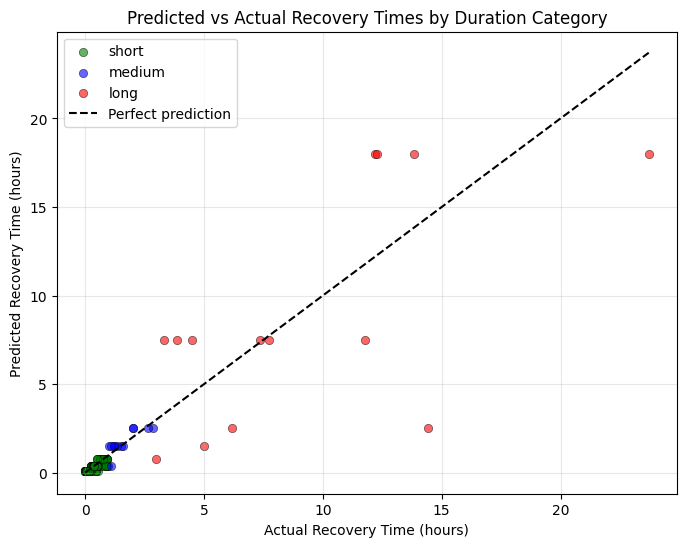

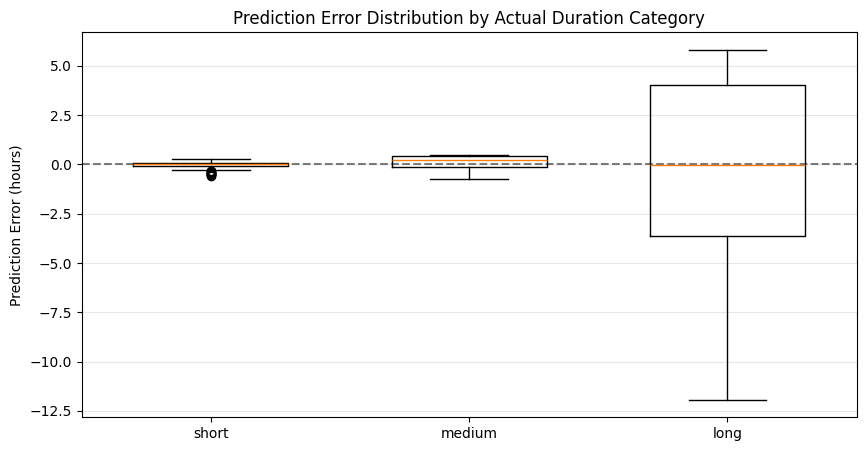

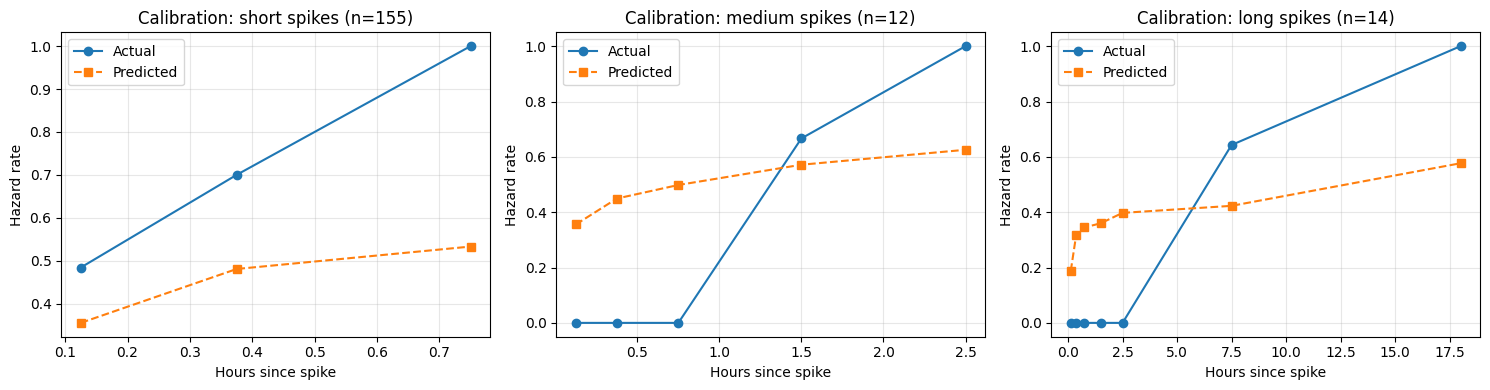

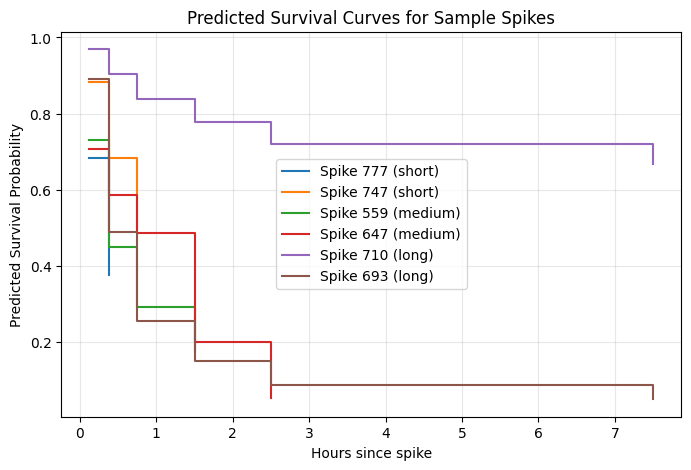

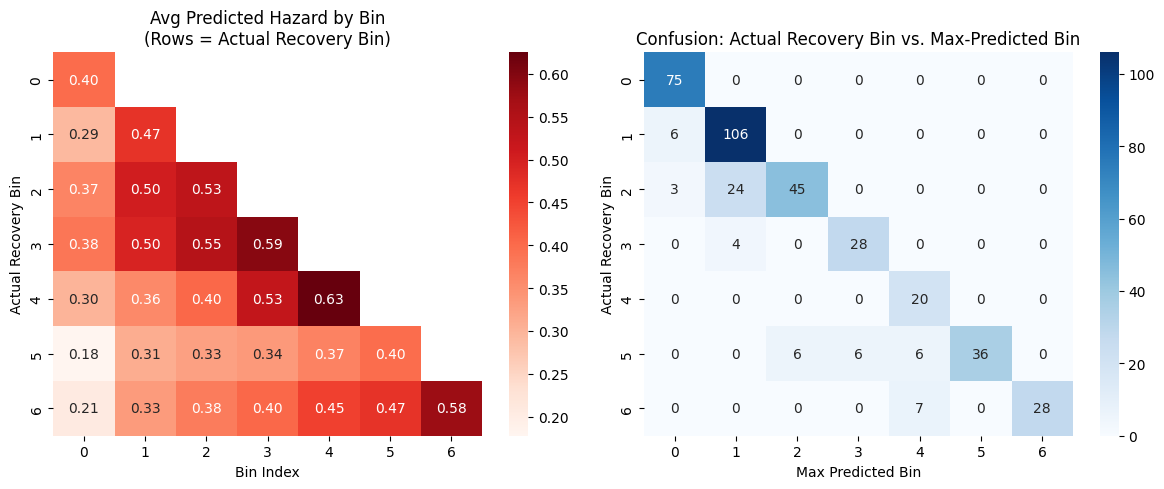

In [123]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


import xgboost as xgb
from sklearn.linear_model import LogisticRegression

def train_discrete_hazard_model(
    train_df,
    val_df=None,
    test_df=None,
    feature_cols=None,
    target_col='event',
    scale_numeric=True,
    model_type='logistic',          # 'logistic' or 'xgboost'
    compute_pvalues=True,           # only for logistic
    class_weight='balanced',        # logistic only
    xgb_params=None,                 # optional XGBoost hyperparameters
    run_optuna=False,
    n_trials=30,
    optuna_timeout=None,
):
    """
    Train a discrete‑time hazard model using logistic regression or XGBoost.

    Parameters
    ----------
    model_type : str, default 'logistic'
        Type of model: 'logistic' (statsmodels for inference) or 'xgboost'.
    xgb_params : dict, optional
        XGBoost parameters. If None, uses defaults: max_depth=3, learning_rate=0.1,
        n_estimators=100, subsample=0.8, colsample_bytree=0.8, scale_pos_weight
        computed from class imbalance.
    (Other parameters as before)

    Returns
    -------
    dict with 'model', 'coef_df' (or 'feature_importance'), 'metrics', etc.
    """
    # Feature preparation (same as before)
    if feature_cols is None:
        exclude = ['spike_id', 'market', 'event', 'bin_idx', 'bin_start_hours',
                   'bin_end_hours', 'trigger_datetime', 'split', 'trigger_date']
        feature_cols = [c for c in train_df.columns if c not in exclude
                        and train_df[c].dtype in ['int64', 'float64', 'int32', 'float32']]

    X_train = train_df[feature_cols].copy().fillna(train_df[feature_cols].median())
    y_train = train_df[target_col].values

    # Preprocessing pipeline (scaling + one-hot encoding)
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = [c for c in feature_cols if c not in cat_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler() if scale_numeric else 'passthrough', num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ], remainder='drop')

    # ------------------------------------------------------------------
    # Model Training
    # ------------------------------------------------------------------
    if model_type == 'logistic':
        if compute_pvalues:
            # Statsmodels path
            X_train_trans = preprocessor.fit_transform(X_train)
            ohe = preprocessor.named_transformers_['cat']
            cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist() if cat_cols else []
            all_feature_names = num_cols + cat_feature_names

            X_train_sm = sm.add_constant(X_train_trans)
            sm_model = sm.Logit(y_train, X_train_sm).fit(disp=0)
            model = sm_model

            coef_df = pd.DataFrame({
                'feature': ['intercept'] + all_feature_names,
                'coef': sm_model.params,
                'std_err': sm_model.bse,
                'p_value': sm_model.pvalues,
                'significant_05': sm_model.pvalues < 0.05,
                'significant_01': sm_model.pvalues < 0.01,
            })
        else:
            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', LogisticRegression(class_weight=class_weight, max_iter=1000, random_state=42))
            ])
            pipeline.fit(X_train, y_train)
            model = pipeline
            coef_df = None
            all_feature_names = None

    elif model_type == 'xgboost':
        # XGBoost path
        # Preprocess data
        X_train_trans = preprocessor.fit_transform(X_train)
        # Get feature names after encoding
        ohe = preprocessor.named_transformers_['cat']
        cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist() if cat_cols else []
        all_feature_names = num_cols + cat_feature_names

        # Compute scale_pos_weight for imbalance
        neg_count = (y_train == 0).sum()
        pos_count = (y_train == 1).sum()
        scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

        # Prepare validation set for early stopping (if available)
        if val_df is not None:
            X_val = val_df[feature_cols].copy().fillna(train_df[feature_cols].median())
            y_val = val_df[target_col].values
            X_val_trans = preprocessor.transform(X_val)
            eval_set = [(X_train_trans, y_train), (X_val_trans, y_val)]
        else:
            eval_set = None

        # Optuna hyperparameter tuning
        if run_optuna:
            import optuna
            from optuna.samplers import TPESampler
            from optuna.pruners import MedianPruner

            # Define objective function for Optuna
            def objective(trial):
                params = {
                    'max_depth': trial.suggest_int('max_depth', 2, 8),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma': trial.suggest_float('gamma', 0, 5),
                    'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
                    'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
                    'scale_pos_weight': scale_pos_weight,
                    'eval_metric': 'logloss',
                    'use_label_encoder': False,
                    'random_state': 42,
                    'verbosity': 0
                }
                # Optional: incorporate xgb_params as base overrides
                if xgb_params:
                    params.update(xgb_params)

                model = xgb.XGBClassifier(**params)
                if eval_set is not None:
                    model.fit(
                        X_train_trans, y_train,
                        eval_set=eval_set,
                        verbose=False
                    )
                    # Use validation log loss for optimization
                    preds = model.predict_proba(X_val_trans)[:, 1]
                    score = log_loss(y_val, preds)
                else:
                    # Use cross-validation on training set
                    cv_results = xgb.cv(
                        params, xgb.DMatrix(X_train_trans, label=y_train),
                        num_boost_round=params['n_estimators'],
                        nfold=5,
                        metrics='logloss',
                        early_stopping_rounds=10,
                        verbose_eval=False,
                        seed=42
                    )
                    score = cv_results['test-logloss-mean'].min()
                return score

            # Create Optuna study
            study = optuna.create_study(
                direction='minimize',
                sampler=TPESampler(seed=42),
                pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
            )
            study.optimize(objective, n_trials=n_trials, timeout=optuna_timeout)

            # Best parameters
            best_params = study.best_params
            best_params.update({
                'scale_pos_weight': scale_pos_weight,
                'eval_metric': 'logloss',
                'use_label_encoder': False,
                'random_state': 42
            })
            if xgb_params:
                best_params.update(xgb_params)

            # Train final model with best params
            xgb_model = xgb.XGBClassifier(**best_params)
            xgb_model.fit(
                X_train_trans, y_train,
                eval_set=eval_set,
                verbose=False
            )
            model = xgb_model

            # Store study for later inspection
            optuna_study = study
        else:
            # No tuning: use default or user-provided parameters
            default_xgb = {
                'max_depth': 3,
                'learning_rate': 0.1,
                'n_estimators': 100,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'random_state': 42,
                'eval_metric': 'logloss',
                'use_label_encoder': False,
                'scale_pos_weight': scale_pos_weight
            }
            if xgb_params:
                default_xgb.update(xgb_params)

            xgb_model = xgb.XGBClassifier(**default_xgb)
            xgb_model.fit(
                X_train_trans, y_train,
                eval_set=eval_set,
                verbose=False
            )
            model = xgb_model
            optuna_study = None

        # Feature importance (gain by default)
        importance = model.feature_importances_
        coef_df = pd.DataFrame({
            'feature': all_feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        # No p-values for XGBoost
        compute_pvalues = False
    else:
        raise ValueError("model_type must be 'logistic' or 'xgboost'")

    # ------------------------------------------------------------------
    # Evaluation function (unchanged but handles model type)
    # ------------------------------------------------------------------
    def evaluate(df, name, model, preprocessor, all_feature_names, compute_pvalues, model_type):
        X = df[feature_cols].copy().fillna(train_df[feature_cols].median())
        y = df[target_col].values

        if model_type == 'logistic' and compute_pvalues:
            X_trans = preprocessor.transform(X)
            X_sm = sm.add_constant(X_trans)
            y_pred_proba = model.predict(X_sm)
        elif model_type == 'xgboost':
            X_trans = preprocessor.transform(X)
            y_pred_proba = model.predict_proba(X_trans)[:, 1]
        else:  # sklearn logistic
            y_pred_proba = model.predict_proba(X)[:, 1]

        y_pred_class = (y_pred_proba >= 0.5).astype(int)

        metrics = {
            'auc': roc_auc_score(y, y_pred_proba),
            'avg_precision': average_precision_score(y, y_pred_proba),
            'log_loss': log_loss(y, y_pred_proba),
            'brier_score': brier_score_loss(y, y_pred_proba),
            'accuracy': accuracy_score(y, y_pred_class),
            'precision': precision_score(y, y_pred_class, zero_division=0),
            'recall': recall_score(y, y_pred_class, zero_division=0),
            'f1': f1_score(y, y_pred_class, zero_division=0),
            'n_samples': len(y),
            'event_rate': y.mean()
        }
        return metrics, y_pred_proba

    # Evaluate on train/val/test
    train_metrics, _ = evaluate(train_df, 'train', model, preprocessor, all_feature_names, compute_pvalues, model_type)
    val_metrics = None
    if val_df is not None:
        val_metrics, _ = evaluate(val_df, 'val', model, preprocessor, all_feature_names, compute_pvalues, model_type)
    test_metrics = None
    if test_df is not None:
        test_metrics, _ = evaluate(test_df, 'test', model, preprocessor, all_feature_names, compute_pvalues, model_type)

    metrics = {'train': train_metrics, 'val': val_metrics, 'test': test_metrics}

    # Prepare result
    result = {
        'model': model,
        'coef_df': coef_df,
        'metrics': metrics,
        'feature_columns': all_feature_names if all_feature_names else feature_cols,
        'preprocessor': preprocessor,
        'compute_pvalues': compute_pvalues,
        'model_type': model_type
    }

    # Print summary
    print("\n" + "="*60)
    print(f"Model Training Complete ({model_type.upper()})")
    print("="*60)
    print(f"Train AUC: {train_metrics['auc']:.4f} | LogLoss: {train_metrics['log_loss']:.4f}")
    if val_metrics:
        print(f"Val   AUC: {val_metrics['auc']:.4f} | LogLoss: {val_metrics['log_loss']:.4f}")
    if test_metrics:
        print(f"Test  AUC: {test_metrics['auc']:.4f} | LogLoss: {test_metrics['log_loss']:.4f}")

    if model_type == 'logistic' and coef_df is not None:
        sig_feats = coef_df[coef_df['significant_05'] & (coef_df['feature'] != 'intercept')]
        print(f"\nSignificant features (p<0.05): {len(sig_feats)}")
        if len(sig_feats) > 0:
            print(sig_feats[['feature', 'coef', 'p_value']].head(10).to_string(index=False))
    elif model_type == 'xgboost':
        print(f"\nTop 10 features by gain importance:")
        print(coef_df.head(10).to_string(index=False))

    return result


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from lifelines.utils import concordance_index

def evaluate_model_by_duration_category(
    model,
    hazard_df,
    spikes_list,
    preprocessor=None,
    feature_cols=None,
    bin_edges_hours=(0, 0.5, 1, 3, 6, 12, 24, 48, 72, 120, 168),
    duration_bins={'short': (0, 2), 'medium': (2, 6), 'long': (6, np.inf)},
    compute_pvalues=True,
    target_col='event'
):
    """
    Evaluate discrete‑time hazard model performance stratified by actual recovery duration.

    Parameters
    ----------
    model : statsmodels result object or sklearn Pipeline
        Trained logistic regression model.
    hazard_df : pd.DataFrame
        Time‑expanded dataset (output of build_hazard_dataset).
    spikes_list : list of dict
        Original spike metadata (contains recovery_time_seconds, event flag).
    preprocessor : sklearn ColumnTransformer, optional
        Required if model is statsmodels (no built‑in preprocessing).
    feature_cols : list, optional
        List of feature column names used. If None, auto‑detect.
    bin_edges_hours : tuple
        Bin boundaries in hours (must match those used in dataset creation).
    duration_bins : dict
        Mapping from category name to (min_hours, max_hours).
    compute_pvalues : bool
        Whether model is a statsmodels result object (True) or sklearn Pipeline.
    target_col : str, default 'event'

    Returns
    -------
    dict
        Contains:
        - 'spike_predictions': DataFrame with predicted recovery times per spike.
        - 'metrics_by_category': DataFrame of metrics per duration category.
        - 'figures': dict of matplotlib Figures.
    """
    # ------------------------------------------------------------------
    # 1. Prepare data and feature alignment
    # ------------------------------------------------------------------
    if feature_cols is None:
        exclude = ['spike_id', 'market', 'event', 'bin_idx', 'bin_start_hours',
                   'bin_end_hours', 'trigger_datetime', 'split', 'trigger_date']
        feature_cols = [c for c in hazard_df.columns if c not in exclude
                        and hazard_df[c].dtype in ['int64', 'float64', 'int32', 'float32']]

    # Ensure we have trigger_datetime for merging spike info
    if 'trigger_datetime' not in hazard_df.columns:
        trigger_map = {i: spike['trigger_datetime'] for i, spike in enumerate(spikes_list)}
        hazard_df = hazard_df.copy()
        hazard_df['trigger_datetime'] = hazard_df['spike_id'].map(trigger_map)

    # ------------------------------------------------------------------
    # 2. Predict probabilities per bin
    # ------------------------------------------------------------------
    X = hazard_df[feature_cols].copy()
    X = X.fillna(X.median())

    if compute_pvalues:
        # statsmodels: need to transform with preprocessor first
        X_trans = preprocessor.transform(X)
        X_sm = sm.add_constant(X_trans)
        y_pred_proba = model.predict(X_sm)
    else:
        # sklearn pipeline
        y_pred_proba = model.predict_proba(X)[:, 1]

    hazard_df = hazard_df.copy()
    hazard_df['pred_hazard'] = y_pred_proba

    # ------------------------------------------------------------------
    # 3. Compute predicted recovery time per spike
    # ------------------------------------------------------------------
    # For each spike, we have predicted hazard probabilities for each bin.
    # The expected recovery time (in hours) is sum over bins: P(event in bin) * bin_midpoint.
    # For censored spikes, we can still compute expected time but evaluation is limited.

    bin_midpoints = []
    bin_edges_sec = np.array(bin_edges_hours) * 3600
    for i in range(len(bin_edges_sec)-1):
        mid_sec = (bin_edges_sec[i] + bin_edges_sec[i+1]) / 2
        bin_midpoints.append(mid_sec / 3600)  # in hours

    # Map bin index to midpoint
    bin_idx_to_mid = {idx: mid for idx, mid in enumerate(bin_midpoints)}

    spike_predictions = []
    # for spike_id, group in hazard_df.groupby('spike_id'):
    #     group = group.sort_values('bin_idx')
    #     # Compute survival probability at start of each bin
    #     # S(t) = product_{j<bin} (1 - h_j)
    #     surv = np.cumprod(1 - group['pred_hazard'].values)
    #     # Probability of recovery in each bin = hazard * survival before bin
    #     prob_recovery_in_bin = group['pred_hazard'].values * np.concatenate(([1.0], surv[:-1]))
    #     # Expected recovery time
    #     midpoints = np.array([bin_idx_to_mid[idx] for idx in group['bin_idx']])
    #     expected_time = np.sum(prob_recovery_in_bin * midpoints)

    #     # Also compute probability of recovery within max follow-up
    #     prob_recovered = 1 - surv[-1] if len(surv) > 0 else 0

    #     # Get actual recovery info from spikes_list
    #     spike_meta = spikes_list[spike_id]
    #     actual_time = spike_meta['recovery_time_seconds'] / 3600 if spike_meta['event'] == 1 else np.nan
    #     event = spike_meta['event']

    #     spike_predictions.append({
    #         'spike_id': spike_id,
    #         'market': group.iloc[0]['market'],
    #         'actual_recovery_hours': actual_time,
    #         'predicted_recovery_hours': expected_time,
    #         'prob_recovered': prob_recovered,
    #         'event': event,
    #         'censored': event == 0
    #     })
    for spike_id, group in hazard_df.groupby('spike_id'):
        group = group.sort_values('bin_idx')
        
        # Find bin with highest predicted hazard
        max_hazard_idx = group['pred_hazard'].idxmax()
        max_bin = group.loc[max_hazard_idx, 'bin_idx']
        predicted_time = bin_idx_to_mid[max_bin]  # use midpoint of that bin
        
        # Alternative: use the actual bin start/end for plotting
        predicted_bin_start = bin_edges_hours[max_bin]
        predicted_bin_end = bin_edges_hours[max_bin + 1]
        
        # Get actual recovery info
        spike_meta = spikes_list[spike_id]
        if spike_id == 1:
            print("AAA", spike_meta)
        actual_time = spike_meta['recovery_time_seconds'] / 3600 if spike_meta['event'] == 1 else np.nan
        event = spike_meta['event']
        
        spike_predictions.append({
            'spike_id': spike_id,
            'market': group.iloc[0]['market'],
            'actual_recovery_hours': actual_time,
            'predicted_recovery_hours': predicted_time,
            'predicted_bin': max_bin,
            'predicted_bin_start': predicted_bin_start,
            'predicted_bin_end': predicted_bin_end,
            'event': event,
            'censored': event == 0
        })


    pred_df = pd.DataFrame(spike_predictions)

    # ------------------------------------------------------------------
    # 4. Categorize spikes by actual duration
    # ------------------------------------------------------------------
    def categorize_duration(hours):
        if pd.isna(hours):
            return 'censored'
        for cat, (low, high) in duration_bins.items():
            if low <= hours < high:
                return cat
        return 'other'

    pred_df['duration_category'] = pred_df['actual_recovery_hours'].apply(categorize_duration)
    # For censored, keep as separate category

    # ------------------------------------------------------------------
    # 5. Compute metrics per category
    # ------------------------------------------------------------------
    metrics_list = []
    for cat in pred_df['duration_category'].unique():
        cat_df = pred_df[pred_df['duration_category'] == cat]
        if cat == 'censored':
            # For censored spikes, we can't compute MAE but can compute C-index using predicted probabilities
            # We need to pair actual event times with predicted risk scores.
            # Since we don't have event times for censored, we can't compute standard metrics here.
            n_spikes = len(cat_df)
            metrics_list.append({
                'category': cat,
                'n_spikes': n_spikes,
                'MAE_hours': np.nan,
                'RMSE_hours': np.nan,
                'R2': np.nan,
                'C_index': np.nan,
                'mean_actual': np.nan,
                'mean_predicted': cat_df['predicted_recovery_hours'].mean()
            })
        else:
            actual = cat_df['actual_recovery_hours'].dropna()
            pred = cat_df.loc[actual.index, 'predicted_recovery_hours']
            mae = mean_absolute_error(actual, pred)
            rmse = np.sqrt(np.mean((actual - pred)**2))
            r2 = r2_score(actual, pred) if len(actual) > 1 else np.nan
            # C-index for uncensored only
            try:
                c_idx = concordance_index(actual, pred)
            except:
                c_idx = np.nan

            metrics_list.append({
                'category': cat,
                'n_spikes': len(cat_df),
                'MAE_hours': mae,
                'RMSE_hours': rmse,
                'R2': r2,
                'C_index': c_idx,
                'mean_actual': actual.mean(),
                'mean_predicted': pred.mean()
            })

    metrics_df = pd.DataFrame(metrics_list)

    # ------------------------------------------------------------------
    # 6. Visualizations
    # ------------------------------------------------------------------
    figures = {}

    # Figure 1: Scatter plot of predicted vs actual recovery times
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    plot_df = pred_df[pred_df['event'] == 1].copy()
    colors = {'short': 'green', 'medium': 'blue', 'long': 'red'}
    for cat, color in colors.items():
        cat_data = plot_df[plot_df['duration_category'] == cat]
        if not cat_data.empty:
            ax1.scatter(cat_data['actual_recovery_hours'], cat_data['predicted_recovery_hours'],
                       c=color, label=cat, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Add diagonal line
    max_val = max(plot_df['actual_recovery_hours'].max(), plot_df['predicted_recovery_hours'].max())
    ax1.plot([0, max_val], [0, max_val], 'k--', label='Perfect prediction')
    ax1.set_xlabel('Actual Recovery Time (hours)')
    ax1.set_ylabel('Predicted Recovery Time (hours)')
    ax1.set_title('Predicted vs Actual Recovery Times by Duration Category')
    ax1.legend()
    ax1.grid(alpha=0.3)
    figures['scatter'] = fig1

    # Figure 2: Error distribution by category
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    error_df = plot_df.copy()
    error_df['error'] = error_df['predicted_recovery_hours'] - error_df['actual_recovery_hours']
    for i, cat in enumerate(['short', 'medium', 'long']):
        cat_errors = error_df[error_df['duration_category'] == cat]['error']
        if not cat_errors.empty:
            ax2.boxplot(cat_errors, positions=[i+1], widths=0.6, labels=[cat])
    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.set_ylabel('Prediction Error (hours)')
    ax2.set_title('Prediction Error Distribution by Actual Duration Category')
    ax2.grid(alpha=0.3, axis='y')
    figures['error_boxplot'] = fig2

    # Figure 3: Mean predicted vs actual per bin (calibration of hazard per bin)
    # Group by bin index and duration category to see if hazard calibration differs
    fig3, axes = plt.subplots(1, 3, figsize=(15, 4))
    bin_edges_hours_list = list(bin_edges_hours)
    for ax, cat in zip(axes, ['short', 'medium', 'long']):
        cat_spike_ids = pred_df[pred_df['duration_category'] == cat]['spike_id'].unique()
        cat_hazard = hazard_df[hazard_df['spike_id'].isin(cat_spike_ids)]
        if cat_hazard.empty:
            ax.text(0.5, 0.5, f'No data for {cat}', ha='center', va='center')
            continue
        # Aggregate by bin_idx
        bin_summary = cat_hazard.groupby('bin_idx').agg(
            actual_hazard=('event', 'mean'),
            pred_hazard_mean=('pred_hazard', 'mean')
        ).reset_index()
        bin_summary['bin_mid'] = bin_summary['bin_idx'].map(bin_idx_to_mid)
        ax.plot(bin_summary['bin_mid'], bin_summary['actual_hazard'], 'o-', label='Actual')
        ax.plot(bin_summary['bin_mid'], bin_summary['pred_hazard_mean'], 's--', label='Predicted')
        ax.set_xlabel('Hours since spike')
        ax.set_ylabel('Hazard rate')
        ax.set_title(f'Calibration: {cat} spikes (n={len(cat_spike_ids)})')
        ax.legend()
        ax.grid(alpha=0.3)
    fig3.tight_layout()
    figures['calibration_by_category'] = fig3

    # Figure 4: Survival curves for sample spikes
    fig4, ax4 = plt.subplots(figsize=(8, 5))
    # Pick a few spikes from each category to illustrate
    sample_ids = []
    for cat in ['short', 'medium', 'long']:
        cat_ids = pred_df[pred_df['duration_category'] == cat]['spike_id'].unique()
        if len(cat_ids) > 0:
            sample_ids.extend(np.random.choice(cat_ids, min(2, len(cat_ids)), replace=False))
    for sid in sample_ids:
        spike_hazard = hazard_df[hazard_df['spike_id'] == sid].sort_values('bin_idx')
        surv = np.cumprod(1 - spike_hazard['pred_hazard'].values)
        midpoints = [bin_idx_to_mid[idx] for idx in spike_hazard['bin_idx']]
        ax4.step(midpoints, surv, where='post', label=f"Spike {sid} ({pred_df[pred_df['spike_id']==sid]['duration_category'].iloc[0]})")
    ax4.set_xlabel('Hours since spike')
    ax4.set_ylabel('Predicted Survival Probability')
    ax4.set_title('Predicted Survival Curves for Sample Spikes')
    ax4.legend()
    ax4.grid(alpha=0.3)
    figures['sample_survival'] = fig4


    fig5, axes5 = plt.subplots(1, 2, figsize=(12, 5))

    # Only use recovered spikes (event==1)
    recovered_hazard = hazard_df[hazard_df['spike_id'].isin(pred_df[pred_df['event']==1]['spike_id'])]
    # Map each spike to its actual recovery bin (first bin where event==1)
    actual_recovery_bin = recovered_hazard[recovered_hazard['event']==1].groupby('spike_id')['bin_idx'].first()
    recovered_hazard['actual_recovery_bin'] = recovered_hazard['spike_id'].map(actual_recovery_bin)

    # Panel A: Heatmap of average predicted hazard by bin_idx and actual_recovery_bin
    heatmap_data = recovered_hazard.groupby(['actual_recovery_bin', 'bin_idx'])['pred_hazard'].mean().unstack()
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Reds', ax=axes5[0])
    axes5[0].set_title('Avg Predicted Hazard by Bin\n(Rows = Actual Recovery Bin)')
    axes5[0].set_xlabel('Bin Index')
    axes5[0].set_ylabel('Actual Recovery Bin')

    # Panel B: Distribution of predicted max-probability bin vs actual recovery bin
    # For each spike, find bin with highest predicted hazard
    max_pred_bin = recovered_hazard.loc[recovered_hazard.groupby('spike_id')['pred_hazard'].idxmax()].set_index('spike_id')['bin_idx']
    recovered_hazard['max_pred_bin'] = recovered_hazard['spike_id'].map(max_pred_bin)
    confusion = pd.crosstab(recovered_hazard['actual_recovery_bin'], recovered_hazard['max_pred_bin'])
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=axes5[1])
    axes5[1].set_title('Confusion: Actual Recovery Bin vs. Max-Predicted Bin')
    axes5[1].set_xlabel('Max Predicted Bin')
    axes5[1].set_ylabel('Actual Recovery Bin')

    print("\nAverage Predicted Hazard by Actual Recovery Bin (rows) and Bin Index (columns):")
    print(heatmap_data.round(3).to_string())


    fig5.tight_layout()
    figures['bin_comparison'] = fig5


    # ------------------------------------------------------------------
    # 7. Return results
    # ------------------------------------------------------------------
    return {
        'spike_predictions': pred_df,
        'metrics_by_category': metrics_df,
        'figures': figures
    }

results = train_discrete_hazard_model(
    train_df=splits["train"],
    val_df=splits["val"],
    test_df=splits["test"],
    feature_cols=None,   # automatically selects numeric columns
    target_col='event',
    scale_numeric=True,
    # class_weight='balanced',
    class_weight=2,
    compute_pvalues=True,
    model_type='logistic',
    # model_type='xgboost',
    run_optuna=True,
    n_trials=50,
)

# Access outputs
model = results['model']
coef_df = results['coef_df']
metrics = results['metrics']

# Inspect top coefficients
if coef_df is not None:
    try:
        top_features = coef_df[coef_df['feature'] != 'intercept'].sort_values('p_value').head(30)
        print(top_features[['feature', 'coef', 'p_value', 'significant_05']])
    except Exception as e:
        pass

# Evaluate by duration category
df_for_display = hazard_df
df_for_display = pd.concat([splits["test"],splits["val"]], ignore_index=True)
eval_results = evaluate_model_by_duration_category(
    model=results['model'],
    hazard_df=df_for_display,
    spikes_list=spikes,
    preprocessor=results.get('preprocessor'),
    feature_cols=results['feature_columns'],
    compute_pvalues=results['compute_pvalues'],
    bin_edges_hours=BIN_EDGES,
    duration_bins={'short': (0, 1), 'medium': (1, 3), 'long': (3, np.inf)},
)

# View metrics
print(eval_results['metrics_by_category'])

# Display figures
for name, fig in eval_results['figures'].items():
    fig.show()



### Train model on all markets

Processing  eth_rlp_usdc
Dates range before cutting 2025-01-02 04:12:23 - 2026-03-15 14:02:59 - , after cutting 2025-01-09 16:23:47 - 2026-03-15 13:58:11 - 
Collected 784 spikes (0, 0.25, 0.5, 1, 2, 3, 12, 24)
Market 'eth_rlp_usdc': 784 spikes → train=628, val=78, test=78

Total rows: 1829
Train: 1464 rows (628 spikes)
Val:   168 rows (78 spikes)
Test:  197 rows (78 spikes)
Processed eth_rlp_usdc: 784 spikes
Processing  eth_reusd_usdc
Dates range before cutting 2025-08-03 23:02:59 - 2026-03-10 15:43:23 - , after cutting 2025-08-14 15:59:11 - 2026-03-10 15:41:59 - 
Collected 189 spikes (0, 0.25, 0.5, 1, 2, 3, 12, 24)
Market 'eth_reusd_usdc': 189 spikes → train=152, val=18, test=19

Total rows: 608
Train: 505 rows (152 spikes)
Val:   69 rows (18 spikes)
Test:  34 rows (19 spikes)
Processed eth_reusd_usdc: 189 spikes
Processing  eth_usr_usdc
Dates range before cutting 2025-01-02 04:06:35 - 2026-03-15 14:03:11 - , after cutting 2025-01-08 00:17:23 - 2025-09-04 07:30:11 - 
Collected 749 spi

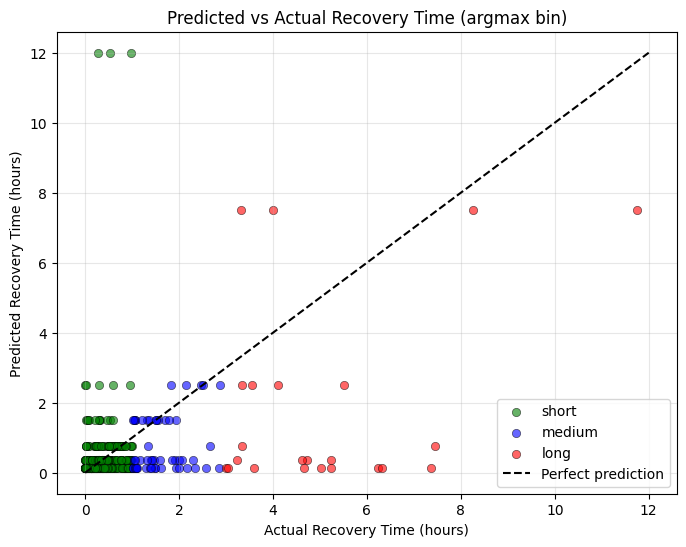

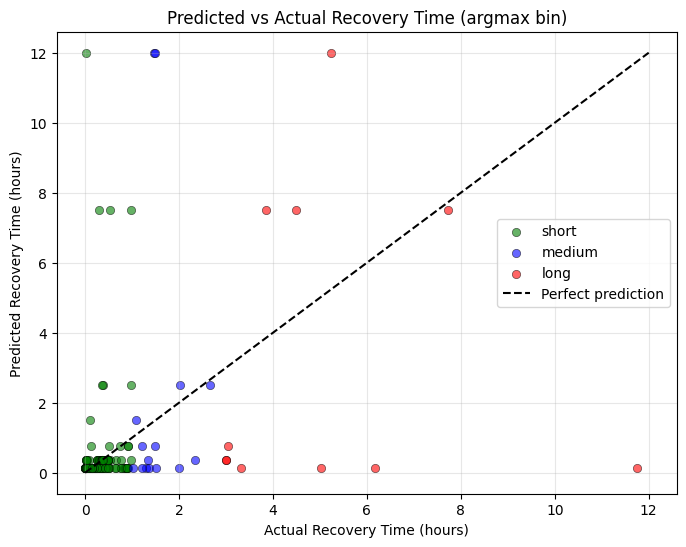


OVERALL TEST PERFORMANCE
auc: 0.7213
log_loss: 0.6202
brier: 0.2103

PER-MARKET TEST PERFORMANCE
          market  n_spikes  n_rows      auc  log_loss    brier
eth_mapollo_usdc         3      16 0.964286  0.327457 0.091334
  eth_reusd_usdc        37     103 0.812675  0.498404 0.161219
    eth_rlp_usdc       156     365 0.770857  0.540051 0.181120
    eth_usr_usdc       149     281 0.554829  0.785528 0.273035


In [178]:
# print(f"Dates range before cutting {df['datetime'].min()} - {df['datetime'].max()} - ", end='')
# thr = df["total_supply_after"].max() * 0.01
# cutoff_min_ts = df[(df["total_supply_after"] > thr) | (df["total_supply_before"] > thr)]["timestamp"].min()
# cutoff_max_ts = df[(df["total_supply_after"] > thr) | (df["total_supply_before"] > thr)]["timestamp"].max()
# df = df[
#     (df["timestamp"] > cutoff_min_ts) & 
#     (df["timestamp"] < cutoff_max_ts)
# ]



import os
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss


def plot_predicted_vs_actual_duration(
    model,
    hazard_df,
    spikes_list,
    preprocessor,
    feature_cols,
    bin_edges_hours,
    model_type,
    compute_pvalues,
    duration_bins=None,
    save_path=None,
    show_plot=True
):
    """
    Scatter plot of predicted vs actual recovery time (hours) for recovered spikes.
    Prediction = midpoint of bin with highest predicted hazard.
    """
    if duration_bins is None:
        duration_bins = {'short': (0, 1), 'medium': (1, 3), 'long': (3, np.inf)}

    X = hazard_df[feature_cols].copy().fillna(hazard_df[feature_cols].median())
    
    if model_type == 'logistic' and compute_pvalues:
        X_trans = preprocessor.transform(X)
        import statsmodels.api as sm
        X_sm = sm.add_constant(X_trans)
        y_pred_proba = model.predict(X_sm)
    elif model_type == 'xgboost':
        X_trans = preprocessor.transform(X)
        y_pred_proba = model.predict_proba(X_trans)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X)[:, 1]
    
    hazard_df = hazard_df.copy()
    hazard_df['pred_hazard'] = y_pred_proba
    
    bin_midpoints = []
    bin_edges_sec = np.array(bin_edges_hours) * 3600
    for i in range(len(bin_edges_sec) - 1):
        mid_sec = (bin_edges_sec[i] + bin_edges_sec[i+1]) / 2
        bin_midpoints.append(mid_sec / 3600)
    bin_idx_to_mid = {idx: mid for idx, mid in enumerate(bin_midpoints)}
    
    spike_predictions = []
    for spike_id, group in hazard_df.groupby('spike_id'):
        group = group.sort_values('bin_idx')
        max_bin = group.loc[group['pred_hazard'].idxmax(), 'bin_idx']
        pred_time = bin_idx_to_mid[max_bin]
        spike_meta = spikes_list[spike_id]
        actual_time = spike_meta['recovery_time_seconds'] / 3600 if spike_meta['event'] == 1 else np.nan
        if spike_meta['event'] == 1 and actual_time < 12:
            spike_predictions.append({
                'spike_id': spike_id,
                'actual_hours': actual_time,
                'predicted_hours': min(pred_time, 12)
            })
    
    pred_df = pd.DataFrame(spike_predictions)
    if pred_df.empty:
        print("No recovered spikes to plot.")
        return None
    
    def cat_duration(h):
        for name, (low, high) in duration_bins.items():
            if low <= h < high:
                return name
        return 'other'
    pred_df['category'] = pred_df['actual_hours'].apply(cat_duration)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {'short': 'green', 'medium': 'blue', 'long': 'red'}
    for cat, color in colors.items():
        cat_data = pred_df[pred_df['category'] == cat]
        if not cat_data.empty:
            ax.scatter(cat_data['actual_hours'], cat_data['predicted_hours'],
                       c=color, label=cat, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    max_val = max(pred_df['actual_hours'].max(), pred_df['predicted_hours'].max())
    max_val = min(max_val, 12)
    ax.plot([0, max_val], [0, max_val], 'k--', label='Perfect prediction')
    ax.set_xlabel('Actual Recovery Time (hours)')
    ax.set_ylabel('Predicted Recovery Time (hours)')
    ax.set_title('Predicted vs Actual Recovery Time (argmax bin)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    return fig

def train_model_across_markets(
    events_dir,
    hourly_dir,
    market_predicate,
    spike_detection_params=None,
    bin_edges_hours=(0, 0.25, 0.5, 1, 2, 3, 12, 24),
    recovery_buffer=0.02,
    train_frac=0.6,
    val_frac=0.2,
    test_frac=0.2,
    model_type='xgboost',
    run_optuna=False,
    n_trials=30,
    optuna_timeout=None,
    xgb_params=None,
    compute_pvalues=False,
    scale_numeric=True,
    class_weight='balanced',
    random_seed=42
):
    if spike_detection_params is None:
        spike_detection_params = {
            'baseline_window_hours': 24,
            'baseline_gap_seconds': 300,
            'spike_util_threshold': 0.90,
            'min_spike_delta': 0.03,
            'recovery_buffer': 0.02,
            'max_followup_events': 200,
            'actions_limit': 1000,
            'min_episode_events': 1,
            'sustained_recovery_events': 1,
            'min_actions_in_spike': 1,
            'start_date': None
        }

    train_parts = []
    val_parts = []
    test_parts = []
    all_spikes = []
    market_summary = []

    for fname in os.listdir(events_dir):
        if not fname.endswith('.csv'):
            continue
        market_name = fname[:-4]
        if not market_predicate(market_name):
            continue

        events_path = os.path.join(events_dir, fname)
        hourly_path = os.path.join(hourly_dir, fname)

        try:
            df_events = pd.read_csv(events_path)
            df_events = df_events.sort_values('timestamp')
            df_events['market'] = market_name
        except Exception as e:
            print(f"Error loading events for {market_name}: {e}")
            continue

        try:
            df_hourly = pd.read_csv(hourly_path)
            df_hourly = df_hourly.sort_values('timestamp')
            df_hourly['market'] = market_name
        except Exception as e:
            print(f"Error loading hourly for {market_name}: {e}")
            continue


        print("Processing ", market_name)
        print(f"Dates range before cutting {df_events['datetime'].min()} - {df_events['datetime'].max()} - ", end='')
        thr = df_events["total_supply_after"].max() * 0.01
        cutoff_min_ts = df_events[(df_events["total_supply_after"] > thr) | (df_events["total_supply_before"] > thr)]["timestamp"].min()
        cutoff_max_ts = df_events[(df_events["total_supply_after"] > thr) | (df_events["total_supply_before"] > thr)]["timestamp"].max()
        df_events = df_events[
            (df_events["timestamp"] > cutoff_min_ts) & 
            (df_events["timestamp"] < cutoff_max_ts)
        ]
        df_hourly = df_hourly[
            (df_hourly["timestamp"] >= cutoff_min_ts) & 
            (df_hourly["timestamp"] <= cutoff_max_ts)
        ]
        # LARGE_MARKET_THRESHOLD = np.quantile(df["total_borrow_after"], 0.05)
        # df = df[df["total_borrow_after"] > LARGE_MARKET_THRESHOLD].reset_index(drop=True)
        print(f", after cutting {df_events['datetime'].min()} - {df_events['datetime'].max()} - ")
        

        spikes = detect_market_spikes(
            df=df_events,
            start_date=spike_detection_params.get('start_date'),
            baseline_window_hours=spike_detection_params['baseline_window_hours'],
            baseline_gap_seconds=spike_detection_params['baseline_gap_seconds'],
            spike_util_threshold=spike_detection_params['spike_util_threshold'],
            min_spike_delta=spike_detection_params['min_spike_delta'],
            recovery_buffer=spike_detection_params['recovery_buffer'],
            max_followup_events=spike_detection_params['max_followup_events'],
            actions_limit=spike_detection_params['actions_limit'],
            min_episode_events=spike_detection_params['min_episode_events'],
            sustained_recovery_events=spike_detection_params['sustained_recovery_events'],
            min_actions_in_spike=spike_detection_params['min_actions_in_spike']
        )

        if not spikes:
            print(f"No spikes in {market_name}, skipping.")
            continue

        for spike in spikes:
            spike['market'] = market_name
        all_spikes.extend(spikes)
        print(f"Collected {len(spikes)} spikes", bin_edges_hours)

        if len(spikes) < 10:
            print(f"Skipped {market_name} due to low spikes")
            continue

        hazard_df = build_hazard_dataset(
            spikes_list=spikes,
            events_df=df_events,
            market_df=df_hourly,
            bin_edges_hours=bin_edges_hours,
            recovery_buffer=recovery_buffer
        )

        hazard_df = add_trigger_datetime_to_hazard(hazard_df, spikes)

        splits = split_by_market_timeline(
            hazard_df,
            train_frac=train_frac,
            val_frac=val_frac,
            test_frac=test_frac,
            min_train_spikes=3
        )

        train_parts.append(splits['train'])
        val_parts.append(splits['val'])
        test_parts.append(splits['test'])

        market_summary.append({
            'market': market_name,
            'n_spikes': len(spikes),
            'train_spikes': splits['train']['spike_id'].nunique(),
            'val_spikes': splits['val']['spike_id'].nunique(),
            'test_spikes': splits['test']['spike_id'].nunique()
        })

        print(f"Processed {market_name}: {len(spikes)} spikes")

    if not train_parts:
        raise ValueError("No valid markets with spikes found.")

    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    print(f"\nCombined dataset: train={len(train_df)} rows, val={len(val_df)} rows, test={len(test_df)} rows")

    model_results = train_discrete_hazard_model(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        model_type=model_type,
        run_optuna=run_optuna,
        n_trials=n_trials,
        optuna_timeout=optuna_timeout,
        xgb_params=xgb_params,
        compute_pvalues=compute_pvalues,
        scale_numeric=scale_numeric,
        class_weight=class_weight
    )

    def evaluate_on_df(df, model, preprocessor, feature_cols, model_type, compute_pvalues):
        X = df[feature_cols].copy().fillna(df[feature_cols].median())
        y = df['event'].values
        if model_type == 'logistic' and compute_pvalues:
            X_trans = preprocessor.transform(X)
            import statsmodels.api as sm
            X_sm = sm.add_constant(X_trans)
            y_pred_proba = model.predict(X_sm)
        elif model_type == 'xgboost':
            X_trans = preprocessor.transform(X)
            y_pred_proba = model.predict_proba(X_trans)[:, 1]
        else:
            y_pred_proba = model.predict_proba(X)[:, 1]
        return y, y_pred_proba

    preprocessor = model_results['preprocessor']
    feature_cols = model_results['feature_columns']
    model = model_results['model']
    model_type_res = model_results['model_type']
    compute_pvalues_res = model_results.get('compute_pvalues', False)

    combined_eval_df = pd.concat([val_df, test_df], ignore_index=True)
    
    eval_y, eval_pred = evaluate_on_df(combined_eval_df, model, preprocessor, feature_cols, model_type_res, compute_pvalues_res)
    combined_eval_df['pred_hazard'] = eval_pred

    overall_metrics = {
        'auc': roc_auc_score(eval_y, eval_pred),
        'log_loss': log_loss(eval_y, eval_pred),
        'brier': brier_score_loss(eval_y, eval_pred)
    }

    per_market_metrics = []
    for market in combined_eval_df['market'].unique():
        mask = combined_eval_df['market'] == market
        y_market = combined_eval_df.loc[mask, 'event'].values
        pred_market = combined_eval_df.loc[mask, 'pred_hazard'].values
        if len(np.unique(y_market)) < 2:
            auc_market = np.nan
        else:
            auc_market = roc_auc_score(y_market, pred_market)
        per_market_metrics.append({
            'market': market,
            'n_spikes': combined_eval_df.loc[mask, 'spike_id'].nunique(),
            'n_rows': mask.sum(),
            'auc': auc_market,
            'log_loss': log_loss(y_market, pred_market),
            'brier': brier_score_loss(y_market, pred_market)
        })

    per_market_df = pd.DataFrame(per_market_metrics).sort_values('auc', ascending=False)


    train_y, train_pred = evaluate_on_df(train_df, model, preprocessor, feature_cols, model_type_res, compute_pvalues_res)
    train_df_eval = train_df.copy()
    train_df_eval['pred_hazard'] = train_pred

    # Plot training predictions
    plot_predicted_vs_actual_duration(
        model=model,
        hazard_df=train_df_eval,
        spikes_list=all_spikes,
        preprocessor=preprocessor,
        feature_cols=feature_cols,
        bin_edges_hours=bin_edges_hours,
        model_type=model_type_res,
        compute_pvalues=compute_pvalues_res,
        duration_bins={'short': (0, 1), 'medium': (1, 3), 'long': (3, np.inf)},
        save_path=None,
        show_plot=True
    )

    plot_predicted_vs_actual_duration(
        model=model,
        hazard_df=combined_eval_df,
        spikes_list=all_spikes,
        preprocessor=preprocessor,
        feature_cols=feature_cols,
        bin_edges_hours=bin_edges_hours,
        model_type=model_type_res,
        compute_pvalues=compute_pvalues_res,
        duration_bins={'short': (0, 1), 'medium': (1, 3), 'long': (3, np.inf)},
        save_path=None,
        show_plot=True
    )

    print("\n" + "="*80)
    print("OVERALL TEST PERFORMANCE")
    print("="*80)
    for k, v in overall_metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nPER-MARKET TEST PERFORMANCE")
    print("="*80)
    print(per_market_df.to_string(index=False))

    return {
        'model_results': model_results,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'eval_df': combined_eval_df,
        'overall_metrics': overall_metrics,
        'per_market_metrics': per_market_df,
        'market_summary': pd.DataFrame(market_summary),
        'eval_predictions': combined_eval_df,
        'all_spikes': all_spikes
    }


def pt_market_predicate(market_name):
    return market_name in ["eth_usr_usdc", "eth_rlp_usdc", "eth_reusd_usdc", "eth_mapollo_usdc"]
    return market_name in [
        # 'eth_cbbtc_usdc',
        'eth_wbtc_usdc',
        # 'eth_wbtc_usdt',
        'eth_wsteth_usdc',
        'eth_wsteth_usdt',
        'eth_cbbtc_usdt',
        'base_wbtc_usdc',
        'base_wbtc_usdt',
        'eth_usr_usdc',
        'eth_sdeusd_usdc',
        'eth_reusd_usdc',
        'eth_siusd_usdc',
        'eth_stcusd_usdc',
        'eth_mhyper_usdc',
        'eth_csusdl_usdc',
        'eth_wsrusd_usdc',
        'eth_slvlusd_usdc',
        'eth_fxsave_usdc',
        'eth_mapollo_usdc',
        # 'eth_mF-ONE_usdc',
        # 'eth_susde_pyusd',
        'eth_syrupusdc_pyusd',
        'eth_syrupusdc_usdc',
        # 'eth_usd0++_usdc',
        'eth_usde_dai',
        'eth_weth_usdt'
    ]
    return 'PT-' in market_name

# Or include all except certain ones
def all_except_blacklist(market_name):
    blacklist = ['base_cbbtc', 'mainnet_usdc']
    return not any(b in market_name for b in blacklist)

# Paths
EVENTS_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched"
HOURLY_DIR = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data"

# Train XGBoost across all PT markets

spike_params = {
    'start_date': '2025-03-01',
    'baseline_window_hours': 24,
    'spike_util_threshold': 0.90,
    'min_spike_delta': 0.03,
    'recovery_buffer': 0.02,
    'max_followup_events': 200,
    'actions_limit': 100000,
    'min_actions_in_spike': 2,
    # Defaults for parameters you didn't mention:
    'baseline_gap_seconds': 300,
    'min_episode_events': 1,
    'sustained_recovery_events': 1
}
BINS = (0, 0.25, 0.5, 1, 2, 3, 12, 24)
# BINS = (0, 1, 3, 12, 240)

results = train_model_across_markets(
    events_dir=EVENTS_DIR,
    hourly_dir=HOURLY_DIR,
    market_predicate=pt_market_predicate,
    spike_detection_params=spike_params,
    bin_edges_hours=BINS,
    recovery_buffer=0.02,
    train_frac=0.8,
    val_frac=0.1,
    test_frac=0.1,
    model_type='logistic',
    # run_optuna=True,
)
# Access outputs
model = results['model_results']['model']
per_market_df = results['per_market_metrics']
overall_auc = results['overall_metrics']['auc']


In [161]:
results['all_spikes'][0]
market2spikes = {}
for i in results["all_spikes"]:
    if i['market'] not in market2spikes.keys():
        market2spikes[i['market']] = [i]
    else:
        market2spikes[i['market']].append(i)

In [163]:
spikes[0]

{'trigger_datetime': '2025-03-01 03:49:23',
 'recovery_datetime': '2025-03-01 05:43:59',
 'recovery_time_seconds': 6876,
 'event': 1,
 'spike_magnitudes': {'utilization_delta': 0.036077225422972536,
  'peak_utilization': 0.9300953969839548},
 'trigger_event_types': 'MarketWithdraw',
 'market_state': {'total_borrow': 9219373.262491222,
  'total_supply': 10312288.447553502,
  'collateral_price': 1.17,
  'loan_asset_price': 0.999877,
  'debt_before': 0.0,
  'supply_before': 798633.3275826973,
  'utilization_before': 0.8940181715609823},
 'actions_df':                                                 hash            type  \
 1  0xa7f8c29446b021168d178c93be1cb5da9d72f3a2efe4...  MarketWithdraw   
 2  0x56c7232ce6ae9e4212ff688e1d5e955b1d1fa2e45706...    MarketSupply   
 3  0x21d84b500406bd3916ae25ca47d8982aa39c9fd18e3d...    MarketSupply   
 
     timestamp                                user_address        assets  \
 1  1740800963  0x0F359FD18BDa75e9c49bC027E7da59a4b01BF32a  399999834172   


In [168]:
# for i in market2spikes.keys():
#     print("Market", i)
#     for j in market2spikes[i][:5]:
#         display(j["actions_df"][[
#             "datetime",
#             "type",
#             "utilization_before",
#             "utilization_after",
#             "borrow_rate_after",
#             "user_address"
#         ]])
#     print("="*150)
